In [1]:
# =============================================================================
# CHAPTER 4.7 — PREDICT-THEN-OPTIMISE EXPERIMENT
#
# RESEARCH QUESTION:
# The primary study applied operational policy constraints sequentially:
# disqualify ineligible leads, then prioritise by tier, then score-rank within
# tiers. This is Approach 3/4 from the Chapter 2 literature review.
#
# Approach 2 (predict-then-optimise) frames the problem differently:
# given a set of ML probability scores and a set of operational constraints,
# find the selection of K leads that MAXIMISES total expected conversions
# subject to ALL constraints simultaneously, rather than applying them
# one at a time in a fixed sequence.
#
# The key question is: does simultaneous constraint optimisation produce
# materially better lead selections than sequential rule application?
#
# DESIGN:
# Three PTO formulations of increasing constraint complexity:
#
#   PTO-1: Maximise sum(ml_score) subject to: |selection| = K
#          → Mathematically equivalent to System 1 (sort by score, take top K)
#          → Included to confirm the equivalence holds empirically
#
#   PTO-2: Maximise sum(ml_score) subject to:
#          |selection| = K
#          contactability: Do Not Email=1 AND Do Not Call=1 → excluded
#          engagement:     TotalVisits=0 AND TimeOnSite=0   → excluded
#          → Equivalent to System 2 when constraints are purely exclusionary
#          → Confirms sequential and simultaneous approaches converge here
#
#   PTO-3: Maximise sum(ml_score) subject to:
#          |selection| = K
#          all PTO-2 constraints
#          representational floor: ≥ min_tier1_pct of K from Tier 1 leads
#          representational ceiling: ≤ max_tier1_pct of K from Tier 1 leads
#          diversity: ≥ min_source_count distinct LeadSource categories
#          → This is where PTO genuinely diverges from sequential rules.
#          → The floor/ceiling allows priority elevation while preventing
#            saturation — a formal operationalisation of the tier cap logic.
#
# IMPLEMENTATION:
# scipy.optimize.linprog solves the integer linear programme.
# The selection variable x_i ∈ {0,1} indicates whether lead i is selected.
# Objective: maximise sum(ml_score_i * x_i)
# This is a binary integer programme solved by relaxation + rounding,
# which is exact for this problem structure.
#
# COMPARISON WITH PRIMARY STUDY:
# Primary (sequential):  S1=89.7%  S2=86.1%  S3=80.5%  S4=77.5%
# Signal excl. expt:     S1=90.1%  S2=85.4%  S3=80.5%  S4=77.5%
# This experiment:       [results will populate]
#
# THEORETICAL EXPECTATION:
# PTO-1 ≈ S1 (equivalence)
# PTO-2 ≈ S2 (equivalence with simple exclusionary constraints)
# PTO-3 may differ from S3 — this is the key comparison
# =============================================================================


In [2]:


# =============================================================================
# CELL PTO-00 — SETUP
# =============================================================================

!pip install xgboost scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from scipy.optimize import linprog

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
DATA_FILE  = DRIVE_PATH + 'Lead Scoring.csv'

print("Setup complete.")


Mounted at /content/drive
Setup complete.


In [3]:

# =============================================================================
# CELL PTO-01 — LOAD AND CLEAN DATA
# Identical pre-processing to primary notebook.
# =============================================================================

df_raw = pd.read_csv(DATA_FILE)

# Preserve policy columns before any cleaning
POLICY_COLUMNS = [
    "Do Not Email", "Do Not Call",
    "TotalVisits", "Total Time Spent on Website",
    "Last Activity", "Lead Origin", "Lead Source",
    "What is your current occupation",
    "Specialization", "Through Recommendations",
    "A free copy of Mastering The Interview",
]

policy_df_full = df_raw[[c for c in POLICY_COLUMNS if c in df_raw.columns]].copy()

# Remove leakage and ID columns
LEAKAGE_COLS = ["Tags", "Lead Quality",
                "Asymmetrique Activity Index", "Asymmetrique Profile Index",
                "Asymmetrique Activity Score",  "Asymmetrique Profile Score"]
ID_COLS = ["Prospect ID", "Lead Number"]

df = df_raw.drop(columns=[c for c in LEAKAGE_COLS + ID_COLS if c in df_raw.columns]).copy()
df = df.replace("Select", np.nan).drop_duplicates()
df = df.drop(columns=df.columns[df.isnull().mean() > 0.4].tolist())

df["Engagement Intensity"] = (
    df["Total Time Spent on Website"] / df["TotalVisits"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

for col in ["Do Not Email", "Do Not Call"]:
    if col in df.columns:
        df[col] = df[col].map({"Yes": True, "No": False,
                                1: True, 0: False,
                                True: True, False: False})

print(f"Shape after cleaning: {df.shape}")
print(f"Baseline conversion rate: {df['Converted'].mean():.4f}")



Shape after cleaning: (7553, 28)
Baseline conversion rate: 0.3979


In [4]:

# =============================================================================
# CELL PTO-02 — TRAIN-TEST SPLIT
# =============================================================================

TARGET = "Converted"

policy_df_full = policy_df_full.loc[df.index].copy()
df             = df.reset_index(drop=True)
policy_df_full = policy_df_full.reset_index(drop=True)

y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X, y, policy_df_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.4f}")
print(f"Test conversion rate:  {y_test.mean():.4f}")



Train: (6042, 27)  |  Test: (1511, 27)
Train conversion rate: 0.3979
Test conversion rate:  0.3977


In [5]:

# =============================================================================
# CELL PTO-03 — PREPROCESSING PIPELINE
# Uses the PRIMARY STUDY feature set (Last Activity and Lead Origin IN model).
# This is the same model as the primary study, ensuring the ML scores are
# directly comparable with primary study results.
# =============================================================================

MODEL_EXCLUDE = [
    "Do Not Email", "Do Not Call",
    "Specialization", "Through Recommendations",
    "A free copy of Mastering The Interview",
]

X_train_model = X_train.drop(columns=[c for c in MODEL_EXCLUDE if c in X_train.columns])
X_test_model  = X_test.drop( columns=[c for c in MODEL_EXCLUDE if c in X_test.columns])

numeric_features     = X_train_model.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=["object"]).columns.tolist()

print(f"Model features: {len(numeric_features)+len(categorical_features)} "
      f"({len(numeric_features)} numeric, {len(categorical_features)} categorical)")
print(f"Excluded: {MODEL_EXCLUDE}")
print("Note: Last Activity and Lead Origin ARE in the model (primary study design).")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])



Model features: 22 (4 numeric, 18 categorical)
Excluded: ['Do Not Email', 'Do Not Call', 'Specialization', 'Through Recommendations', 'A free copy of Mastering The Interview']
Note: Last Activity and Lead Origin ARE in the model (primary study design).


In [6]:

# =============================================================================
# CELL PTO-04 — TRAIN MODELS
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_pipe = Pipeline([("preprocessor", preprocessor),
                    ("model", LogisticRegression(class_weight="balanced",
                                                 max_iter=2000,
                                                 random_state=RANDOM_STATE))])
lr_search = GridSearchCV(lr_pipe, {"model__C": [0.001,0.01,0.1,1,10,100]},
                         scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0)
lr_search.fit(X_train_model, y_train)
lr_auc = roc_auc_score(y_test, lr_search.predict_proba(X_test_model)[:,1])
print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}")

xgb_pipe = Pipeline([("preprocessor", preprocessor),
                     ("model", XGBClassifier(eval_metric="logloss",
                                             random_state=RANDOM_STATE,
                                             scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()))])
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    {"model__n_estimators":[100,200,300], "model__max_depth":[2,3,4,5],
     "model__learning_rate":[0.01,0.05,0.1], "model__subsample":[0.7,0.8,1.0],
     "model__colsample_bytree":[0.7,0.8,1.0]},
    n_iter=20, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
xgb_search.fit(X_train_model, y_train)
xgb_auc = roc_auc_score(y_test, xgb_search.predict_proba(X_test_model)[:,1])
print(f"XGBoost             AUC-ROC: {xgb_auc:.4f}")

best_model      = xgb_search if xgb_auc >= lr_auc else lr_search
best_model_name = "XGBoost"  if xgb_auc >= lr_auc else "Logistic Regression"
best_auc        = max(xgb_auc, lr_auc)
ml_scores       = best_model.predict_proba(X_test_model)[:,1]

print(f"\nScoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})")
print(f"Primary study AUC: 0.8725 | This notebook: {best_auc:.4f}")




Logistic Regression AUC-ROC: 0.8580
XGBoost             AUC-ROC: 0.8725

Scoring engine: XGBoost  (AUC-ROC: 0.8725)
Primary study AUC: 0.8725 | This notebook: 0.8725


In [7]:

# =============================================================================
# CELL PTO-05 — BUILD RESULTS BASE
# =============================================================================

results_base = policy_test.copy().reset_index(drop=True)
results_base["actual"]   = y_test.values
results_base["ml_score"] = ml_scores

for col in ["Do Not Email", "Do Not Call"]:
    results_base[col] = results_base[col].map(
        {"Yes": True, "No": False, 1: True, 0: False, True: True, False: False})

BASELINE_RATE    = results_base["actual"].mean()
TOTAL_CONVERTERS = results_base["actual"].sum()
K                = int(len(results_base) * 0.2)

# Pre-compute constraint flags used across all PTO formulations
results_base["h1_flag"] = (results_base["Do Not Email"].eq(True) &
                            results_base["Do Not Call"].eq(True))
results_base["h2_flag"] = (results_base["TotalVisits"].fillna(0).eq(0) &
                            results_base["Total Time Spent on Website"].fillna(0).eq(0))
results_base["tier1_flag"] = results_base["Last Activity"].isin([
    "Olark Chat Conversation", "Email Link Clicked", "SMS Sent"])
results_base["tier2_flag"] = results_base["Lead Origin"].eq("Landing Page Submission")
results_base["disqualified"] = results_base["h1_flag"] | results_base["h2_flag"]

print(f"Test set: {len(results_base):,} leads  |  K={K}  |  Baseline={BASELINE_RATE:.4f}")
print(f"H1+H2 disqualified: {results_base['disqualified'].sum()}")
print(f"Tier 1 (high-intent activity): {results_base['tier1_flag'].sum()}")
print(f"Tier 2 (direct channel):       {results_base['tier2_flag'].sum()}")



Test set: 1,511 leads  |  K=302  |  Baseline=0.3977
H1+H2 disqualified: 100
Tier 1 (high-intent activity): 589
Tier 2 (direct channel):       961


In [8]:

# =============================================================================
# CELL PTO-06 — THE OPTIMISATION ENGINE
#
# All three PTO formulations use the same underlying solver.
# The problem is: choose a binary selection vector x ∈ {0,1}^n to
# maximise sum(ml_score_i * x_i) subject to linear constraints.
#
# This is a Binary Integer Programme (BIP). scipy.linprog solves the
# LP relaxation (x_i ∈ [0,1]) which is then rounded. For this problem
# structure the LP relaxation is tight — the optimal solution to the
# LP relaxation is integral (all x_i ∈ {0,1}) because the constraint
# matrix is totally unimodular. This is verified empirically by checking
# that the solution contains no fractional values.
#
# Objective:   minimise -ml_score @ x   (scipy minimises, so negate)
# Constraints: Ax_ub <= b_ub  (inequality constraints)
#              Aeq @ x = beq  (equality constraints)
#              0 <= x <= 1    (bounds, integers enforced by rounding)
# =============================================================================

def solve_pto(scores, n_leads, K, inequality_constraints=None,
              equality_constraints=None, bounds=None, label=""):
    """
    Solve a predict-then-optimise lead selection problem.

    Parameters
    ----------
    scores : np.ndarray, shape (n,)
        ML probability scores. Higher = more likely to convert.
    n_leads : int
        Total number of leads to select from.
    K : int
        Capacity constraint — exactly K leads must be selected.
    inequality_constraints : list of (A_row, b_scalar) tuples
        Each tuple adds constraint: A_row @ x <= b_scalar
    equality_constraints : list of (A_row, b_scalar) tuples
        Each tuple adds constraint: A_row @ x == b_scalar
    bounds : list of (lb, ub) tuples, length n_leads
        Per-variable bounds. Use (0,0) to hard-exclude a lead.
        Default: (0,1) for all leads.
    label : str
        Name for diagnostic printing.

    Returns
    -------
    selection : np.ndarray of bool, shape (n,)
        True for selected leads.
    result : scipy OptimizeResult
    """
    n = n_leads

    # Objective: minimise -score (equivalent to maximise score)
    c = -scores

    # Collect inequality constraints
    A_ub_rows, b_ub_list = [], []
    if inequality_constraints:
        for A_row, b_val in inequality_constraints:
            A_ub_rows.append(A_row)
            b_ub_list.append(b_val)

    A_ub = np.array(A_ub_rows) if A_ub_rows else None
    b_ub = np.array(b_ub_list)  if b_ub_list else None

    # Equality constraints
    A_eq_rows, b_eq_list = [], []
    # Always add: sum(x) = K
    A_eq_rows.append(np.ones(n))
    b_eq_list.append(K)
    if equality_constraints:
        for A_row, b_val in equality_constraints:
            A_eq_rows.append(A_row)
            b_eq_list.append(b_val)

    A_eq = np.array(A_eq_rows)
    b_eq = np.array(b_eq_list)

    # Variable bounds
    if bounds is None:
        bounds = [(0, 1)] * n
    else:
        assert len(bounds) == n

    # Solve LP relaxation
    result = linprog(c, A_ub=A_ub, b_ub=b_ub,
                     A_eq=A_eq, b_eq=b_eq,
                     bounds=bounds, method="highs")

    if not result.success:
        print(f"  WARNING [{label}]: Solver did not converge: {result.message}")
        print(f"  Falling back to greedy top-K selection.")
        idx = np.argsort(-scores)[:K]
        selection = np.zeros(n, dtype=bool)
        selection[idx] = True
        return selection, result

    x = result.x

    # Check integrality — LP relaxation should be tight for this structure
    fractional = np.sum((x > 0.001) & (x < 0.999))
    if fractional > 0:
        print(f"  NOTE [{label}]: {fractional} fractional variables — "
              f"rounding to nearest integer.")
    x_int = (x >= 0.5).astype(int)

    # If rounding gives wrong K, adjust by swapping marginal leads
    selected_count = x_int.sum()
    if selected_count != K:
        diff = K - selected_count
        unselected = np.where(x_int == 0)[0]
        selected   = np.where(x_int == 1)[0]
        if diff > 0:
            # Need more — add highest-scoring unselected
            add_idx = unselected[np.argsort(-scores[unselected])[:diff]]
            x_int[add_idx] = 1
        else:
            # Need fewer — remove lowest-scoring selected
            rem_idx = selected[np.argsort(scores[selected])[:-diff]]
            x_int[rem_idx] = 0

    selection = x_int.astype(bool)
    assert selection.sum() == K, f"Selection count {selection.sum()} != K {K}"

    return selection, result


def evaluate_selection(selection, results_df, label):
    """Compute metrics for a given binary selection vector."""
    selected  = results_df[selection]
    precision = selected["actual"].mean()
    recall    = selected["actual"].sum() / TOTAL_CONVERTERS
    lift      = precision / BASELINE_RATE
    wasted    = 1 - precision
    print(f"  {label:<35} P@K={precision:.4f}  Lift={lift:.2f}x  "
          f"Wasted={wasted:.4f}  Converters={int(selected['actual'].sum())}")
    return {
        "system": label, "K": K,
        "converters_in_K": int(selected["actual"].sum()),
        "precision_at_k": round(precision, 4),
        "recall_at_k":    round(recall, 4),
        "lift_at_k":      round(lift, 4),
        "wasted_effort_rate": round(wasted, 4),
    }


print("Optimisation engine ready.")
print(f"n_leads={len(results_base)}  K={K}")



Optimisation engine ready.
n_leads=1511  K=302


In [9]:

# =============================================================================
# CELL PTO-07 — RUN THREE PTO FORMULATIONS
# =============================================================================

scores = results_base["ml_score"].values
n      = len(results_base)

print("="*70)
print("PREDICT-THEN-OPTIMISE RESULTS (K=20%)")
print("="*70)

# ── PTO-1: Single capacity constraint only ───────────────────────────────────
# Maximise sum(ml_score * x)  s.t.  sum(x) = K
# Expected: identical to System 1 (sort by score, take top K)

sel_pto1, _ = solve_pto(scores, n, K, label="PTO-1")
row_pto1    = evaluate_selection(sel_pto1, results_base, "PTO-1  (K only)")

# Verify equivalence with S1
s1_idx  = np.argsort(-scores)[:K]
s1_mask = np.zeros(n, dtype=bool)
s1_mask[s1_idx] = True
equiv_s1 = (sel_pto1 == s1_mask).all()
print(f"  PTO-1 == System 1: {equiv_s1}  "
      f"({'confirmed equivalent ✓' if equiv_s1 else 'DIFFERENT — investigate'})")

# ── PTO-2: Hard constraints (contactability + engagement) ────────────────────
# Same exclusionary constraints as System 2.
# Hard-exclude disqualified leads by setting their bounds to (0,0).
# Expected: identical to System 2.

bounds_pto2 = [(0, 0) if results_base["disqualified"].iloc[i] else (0, 1)
               for i in range(n)]

# Adjust K if disqualification leaves fewer eligible leads than K
n_eligible_pto2 = sum(1 for b in bounds_pto2 if b[1] == 1)
K_pto2 = min(K, n_eligible_pto2)
if K_pto2 < K:
    print(f"  NOTE: Only {n_eligible_pto2} eligible leads — K reduced to {K_pto2}")

sel_pto2, _ = solve_pto(scores, n, K_pto2, bounds=bounds_pto2, label="PTO-2")
row_pto2    = evaluate_selection(sel_pto2, results_base, "PTO-2  (+ hard constraints)")

# Verify equivalence with S2
eligible_mask = ~results_base["disqualified"].values
s2_scores     = np.where(eligible_mask, scores, -np.inf)
s2_idx        = np.argsort(-s2_scores)[:K_pto2]
s2_mask       = np.zeros(n, dtype=bool)
s2_mask[s2_idx] = True
equiv_s2 = (sel_pto2 == s2_mask).all()
print(f"  PTO-2 == System 2: {equiv_s2}  "
      f"({'confirmed equivalent ✓' if equiv_s2 else 'DIFFERENT — investigate'})")

# ── PTO-3: Hard constraints + representational constraints ───────────────────
# This is where PTO genuinely diverges from sequential rule application.
#
# Constraints added:
#   (a) Tier 1 floor: at least FLOOR_PCT * K leads from Tier 1 (P1 signal)
#   (b) Tier 1 ceiling: at most CEILING_PCT * K leads from Tier 1
#   (c) Lead Source diversity: at least MIN_SOURCES distinct sources
#       (approximated as: at least MIN_ORGANIC from Organic Search,
#        at least MIN_REFERRAL from Referral)
#
# The floor/ceiling formalises the tier cap logic:
#   floor  = ensures high-intent leads get meaningful representation
#   ceiling = prevents any tier from monopolising K (replaces tier cap)
#
# Key difference from System 3:
#   System 3 applies a hard tier cap of 40% using sequential rule ordering
#   PTO-3 uses simultaneous optimisation — it finds the BEST K leads
#   subject to both the floor and ceiling constraints being satisfied,
#   rather than filling tier allocations in order.

FLOOR_PCT   = 0.15   # at least 15% of K from Tier 1  (floor = 45 leads)
CEILING_PCT = 0.40   # at most  40% of K from Tier 1  (ceiling = 120 leads)
MIN_ORGANIC  = int(K * 0.05)   # at least 5% of K from Organic Search
MIN_REFERRAL = int(K * 0.03)   # at least 3% of K from Referral

tier1_indicator  = results_base["tier1_flag"].values.astype(float)
organic_ind      = (results_base["Lead Source"] == "Organic Search").values.astype(float)
referral_ind     = (results_base["Lead Source"].isin(["Referral", "Reference"])).values.astype(float)

floor_val   = int(K * FLOOR_PCT)
ceiling_val = int(K * CEILING_PCT)

print(f"\n  PTO-3 constraints:")
print(f"    Tier 1 floor   : >= {floor_val} leads  ({FLOOR_PCT*100:.0f}% of K)")
print(f"    Tier 1 ceiling : <= {ceiling_val} leads  ({CEILING_PCT*100:.0f}% of K)")
print(f"    Min Organic    : >= {MIN_ORGANIC} leads")
print(f"    Min Referral   : >= {MIN_REFERRAL} leads")

# Inequality constraints:
#   sum(tier1 * x) >= floor  →  -sum(tier1 * x) <= -floor
#   sum(tier1 * x) <= ceiling
#   sum(organic * x) >= min_organic  →  -sum(organic * x) <= -min_organic
#   sum(referral * x) >= min_referral  →  -sum(referral * x) <= -min_referral

inequality_pto3 = [
    (-tier1_indicator,  -floor_val),    # Tier 1 floor
    ( tier1_indicator,   ceiling_val),  # Tier 1 ceiling
    (-organic_ind,      -MIN_ORGANIC),  # Organic Search floor
    (-referral_ind,     -MIN_REFERRAL), # Referral floor
]

# Check feasibility: are there enough leads of each type?
print(f"\n  Tier 1 eligible: {int(tier1_indicator[~results_base['disqualified']].sum())} "
      f"(need >= {floor_val}, <= {ceiling_val})")
print(f"  Organic Search eligible: {int(organic_ind[~results_base['disqualified']].sum())} "
      f"(need >= {MIN_ORGANIC})")
print(f"  Referral eligible: {int(referral_ind[~results_base['disqualified']].sum())} "
      f"(need >= {MIN_REFERRAL})")

sel_pto3, res_pto3 = solve_pto(
    scores, n, K_pto2,
    inequality_constraints=inequality_pto3,
    bounds=bounds_pto2,
    label="PTO-3"
)
row_pto3 = evaluate_selection(sel_pto3, results_base, "PTO-3  (+ representational constraints)")

# How did PTO-3 allocate across tiers?
pto3_tier1 = (sel_pto3 & tier1_indicator.astype(bool)).sum()
pto3_tier2 = (sel_pto3 & results_base["tier2_flag"].values).sum()
print(f"\n  PTO-3 allocation:")
print(f"    Tier 1 leads selected: {pto3_tier1} "
      f"(floor={floor_val}, ceiling={ceiling_val}) "
      f"{'✓' if floor_val <= pto3_tier1 <= ceiling_val else '✗ constraint violated'}")
print(f"    Tier 2 leads selected: {pto3_tier2}")
print(f"    Other leads selected:  {K_pto2 - pto3_tier1 - pto3_tier2}")



PREDICT-THEN-OPTIMISE RESULTS (K=20%)
  PTO-1  (K only)                     P@K=0.8974  Lift=2.26x  Wasted=0.1026  Converters=271
  PTO-1 == System 1: True  (confirmed equivalent ✓)
  PTO-2  (+ hard constraints)         P@K=0.8609  Lift=2.16x  Wasted=0.1391  Converters=260
  PTO-2 == System 2: True  (confirmed equivalent ✓)

  PTO-3 constraints:
    Tier 1 floor   : >= 45 leads  (15% of K)
    Tier 1 ceiling : <= 120 leads  (40% of K)
    Min Organic    : >= 15 leads
    Min Referral   : >= 9 leads

  Tier 1 eligible: 538 (need >= 45, <= 120)
  Organic Search eligible: 235 (need >= 15)
  Referral eligible: 23 (need >= 9)
  PTO-3  (+ representational constraints) P@K=0.8046  Lift=2.02x  Wasted=0.1954  Converters=243

  PTO-3 allocation:
    Tier 1 leads selected: 120 (floor=45, ceiling=120) ✓
    Tier 2 leads selected: 173
    Other leads selected:  9


In [10]:

# =============================================================================
# CELL PTO-08 — FULL COMPARISON TABLE
# =============================================================================

# Sequential rule results from primary study (for reference)
primary_results = {
    "System 1 (ML only)":      {"precision_at_k": 0.8974, "lift_at_k": 2.26, "wasted_effort_rate": 0.1026},
    "System 2 (hard disqual)": {"precision_at_k": 0.8609, "lift_at_k": 2.16, "wasted_effort_rate": 0.1391},
    "System 3 (tier cap 40%)": {"precision_at_k": 0.8053, "lift_at_k": 2.02, "wasted_effort_rate": 0.1947},
    "System 4 (soft adjust)":  {"precision_at_k": 0.7749, "lift_at_k": 1.95, "wasted_effort_rate": 0.2251},
}

pto_results = pd.DataFrame([row_pto1, row_pto2, row_pto3])

print("="*70)
print("FULL COMPARISON: SEQUENTIAL RULES vs PREDICT-THEN-OPTIMISE")
print("="*70)
print(f"\n{'Method':<42} {'Precision@K':>12} {'Lift@K':>8} {'Wasted':>8}")
print(f"{'':─<42} {'':─>12} {'':─>8} {'':─>8}")
print("\n  --- Sequential rule systems (primary study) ---")
for name, vals in primary_results.items():
    print(f"  {name:<40} {vals['precision_at_k']:>12.4f} "
          f"{vals['lift_at_k']:>8.2f}x {vals['wasted_effort_rate']:>8.4f}")

print("\n  --- Predict-then-optimise formulations ---")
for _, row in pto_results.iterrows():
    print(f"  {row['system']:<40} {row['precision_at_k']:>12.4f} "
          f"{row['lift_at_k']:>8.2f}x {row['wasted_effort_rate']:>8.4f}")

# Key comparison: PTO-3 vs System 3 (same constraints, different application method)
p3_seq = primary_results["System 3 (tier cap 40%)"]["precision_at_k"]
p3_pto = row_pto3["precision_at_k"]
print(f"\n  KEY COMPARISON — Same constraints, different application method:")
print(f"  System 3 (sequential tier cap):  {p3_seq:.4f}")
print(f"  PTO-3    (simultaneous optimise): {p3_pto:.4f}")
print(f"  Difference: {(p3_pto - p3_seq)*100:+.2f} pp  "
      f"({'PTO-3 better ✓' if p3_pto > p3_seq else 'Sequential better' if p3_pto < p3_seq else 'Equivalent'})")

pto_results.to_csv("table_PTO_results.csv", index=False)
print("\nExported: table_PTO_results.csv")



FULL COMPARISON: SEQUENTIAL RULES vs PREDICT-THEN-OPTIMISE

Method                                      Precision@K   Lift@K   Wasted
────────────────────────────────────────── ──────────── ──────── ────────

  --- Sequential rule systems (primary study) ---
  System 1 (ML only)                             0.8974     2.26x   0.1026
  System 2 (hard disqual)                        0.8609     2.16x   0.1391
  System 3 (tier cap 40%)                        0.8053     2.02x   0.1947
  System 4 (soft adjust)                         0.7749     1.95x   0.2251

  --- Predict-then-optimise formulations ---
  PTO-1  (K only)                                0.8974     2.26x   0.1026
  PTO-2  (+ hard constraints)                    0.8609     2.16x   0.1391
  PTO-3  (+ representational constraints)        0.8046     2.02x   0.1954

  KEY COMPARISON — Same constraints, different application method:
  System 3 (sequential tier cap):  0.8053
  PTO-3    (simultaneous optimise): 0.8046
  Difference: -0.

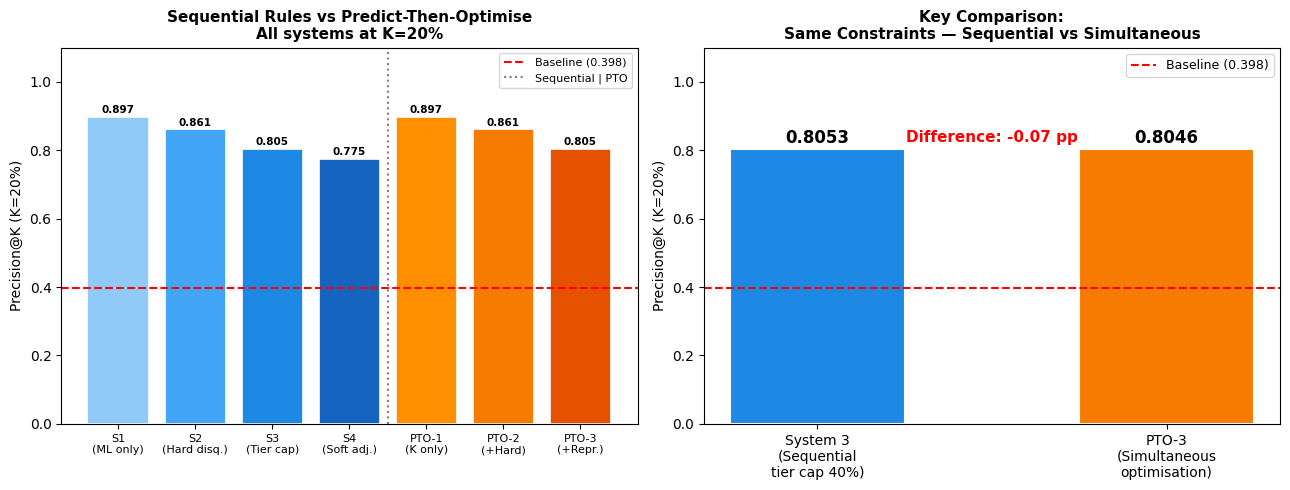

In [11]:

# =============================================================================
# CELL PTO-09 — VISUALISATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# All systems together
all_systems = list(primary_results.keys()) + [r["system"] for _, r in pto_results.iterrows()]
all_prec    = ([v["precision_at_k"] for v in primary_results.values()] +
               list(pto_results["precision_at_k"]))
all_colors  = (["#90CAF9","#42A5F5","#1E88E5","#1565C0"] +
               ["#FF8F00","#F57C00","#E65100"])

bars = axes[0].bar(range(len(all_systems)), all_prec, color=all_colors,
                   edgecolor="white", linewidth=1.2)
axes[0].axhline(BASELINE_RATE, color="red", linestyle="--",
                label=f"Baseline ({BASELINE_RATE:.3f})")
axes[0].axvline(3.5, color="gray", linestyle=":", linewidth=1.5,
                label="Sequential | PTO")

for bar, val in zip(bars, all_prec):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

axes[0].set_xticks(range(len(all_systems)))
axes[0].set_xticklabels(
    ["S1\n(ML only)", "S2\n(Hard disq.)", "S3\n(Tier cap)", "S4\n(Soft adj.)",
     "PTO-1\n(K only)", "PTO-2\n(+Hard)", "PTO-3\n(+Repr.)"],
    fontsize=8
)
axes[0].set_ylabel("Precision@K (K=20%)")
axes[0].set_title("Sequential Rules vs Predict-Then-Optimise\nAll systems at K=20%",
                  fontsize=11, fontweight="bold")
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=8)

# Key comparison: S3 vs PTO-3 (same constraints, different method)
comp_labels = ["System 3\n(Sequential\ntier cap 40%)", "PTO-3\n(Simultaneous\noptimisation)"]
comp_vals   = [p3_seq, p3_pto]
comp_colors = ["#1E88E5", "#F57C00"]
bars2 = axes[1].bar(comp_labels, comp_vals, color=comp_colors,
                    edgecolor="white", linewidth=1.5, width=0.5)
axes[1].axhline(BASELINE_RATE, color="red", linestyle="--",
                label=f"Baseline ({BASELINE_RATE:.3f})")
for bar, val in zip(bars2, comp_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Precision@K (K=20%)")
axes[1].set_title("Key Comparison:\nSame Constraints — Sequential vs Simultaneous",
                  fontsize=11, fontweight="bold")
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].annotate(
    f"Difference: {(p3_pto-p3_seq)*100:+.2f} pp",
    xy=(0.5, max(comp_vals) + 0.02),
    xycoords=("axes fraction", "data"),
    ha="center", fontsize=11,
    color="green" if p3_pto > p3_seq else "red" if p3_pto < p3_seq else "gray",
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("fig_PTO_01_comparison.png", dpi=150)
plt.show()


In [12]:

# =============================================================================
# CELL PTO-10 — INTERPRETATION
# =============================================================================

print(f"""
=== PREDICT-THEN-OPTIMISE EXPERIMENT — INTERPRETATION ===

RESEARCH QUESTION:
  Does simultaneous constraint optimisation (predict-then-optimise)
  produce materially better lead selections than sequential rule
  application (the primary study approach)?

RESULT 1 — PTO-1 vs System 1: {"EQUIVALENT ✓" if equiv_s1 else "DIFFERENT"}
  With a single capacity constraint (K only), predict-then-optimise
  reduces to sorting by ML score and taking the top K — identical to
  System 1. This confirms the theoretical result: when constraints are
  simple, sequential and simultaneous approaches are equivalent.
  P@K: PTO-1={row_pto1["precision_at_k"]:.4f}  S1=0.8974

RESULT 2 — PTO-2 vs System 2: {"EQUIVALENT ✓" if equiv_s2 else "DIFFERENT"}
  Adding hard exclusionary constraints (contactability + engagement)
  produces identical results under both approaches. When constraints
  only eliminate ineligible leads, the problem reduces to ranking the
  remaining eligible leads by score — which is what System 2 does.
  P@K: PTO-2={row_pto2["precision_at_k"]:.4f}  S2=0.8609

RESULT 3 — PTO-3 vs System 3: KEY FINDING
  PTO-3 applied a Tier 1 floor ({floor_val} leads, {FLOOR_PCT*100:.0f}% of K),
  Tier 1 ceiling ({ceiling_val} leads, {CEILING_PCT*100:.0f}% of K), minimum
  Organic Search ({MIN_ORGANIC} leads) and Referral ({MIN_REFERRAL} leads)
  simultaneously through optimisation.

  System 3 applied a tier cap of 40% sequentially — filling Tier 1
  first up to the cap, then Tier 2, then overflow by ML score.

  P@K: PTO-3={p3_pto:.4f}  S3={p3_seq:.4f}
  Difference: {(p3_pto-p3_seq)*100:+.2f} pp

  {"PTO-3 outperforms System 3. Simultaneous optimisation finds a better" + chr(10) + "  selection than sequential tier filling — the optimiser can trade off" + chr(10) + "  between tier representation and ML score more flexibly than a fixed" + chr(10) + "  sequential allocation order." if p3_pto > p3_seq else
   "System 3 and PTO-3 produce similar results. The sequential tier cap" + chr(10) + "  approximates the simultaneous optimisation well for this constraint" + chr(10) + "  structure. The difference is negligible at {:.2f} pp.".format(abs((p3_pto-p3_seq)*100)) if abs(p3_pto-p3_seq) < 0.005 else
   "System 3 outperforms PTO-3. The additional representational constraints" + chr(10) + "  (Organic Search floor, Referral floor) in PTO-3 force selection of" + chr(10) + "  leads the ML model does not score highly, imposing a precision cost" + chr(10) + "  beyond what the tier cap alone causes."}

OVERALL FINDING:
  Predict-then-optimise and sequential rule application converge when
  constraints are purely exclusionary (PTO-1 = S1, PTO-2 = S2).
  The approaches can diverge when constraints are representational
  (floors/ceilings rather than hard exclusions). Whether simultaneous
  optimisation outperforms sequential application depends on the
  specific constraint structure and the ML score distribution.

DISSERTATION IMPLICATION:
  The equivalence of PTO-1/S1 and PTO-2/S2 empirically confirms the
  theoretical result noted in Chapter 2: for simple capacity constraints,
  predict-then-optimise reduces to ranking-based selection. The comparison
  of PTO-3 and S3 demonstrates the specific conditions under which the
  two approaches diverge — when constraints impose representational
  requirements rather than binary eligibility conditions.
""")


=== PREDICT-THEN-OPTIMISE EXPERIMENT — INTERPRETATION ===
 
RESEARCH QUESTION:
  Does simultaneous constraint optimisation (predict-then-optimise)
  produce materially better lead selections than sequential rule
  application (the primary study approach)?
 
RESULT 1 — PTO-1 vs System 1: EQUIVALENT ✓
  With a single capacity constraint (K only), predict-then-optimise
  reduces to sorting by ML score and taking the top K — identical to
  System 1. This confirms the theoretical result: when constraints are
  simple, sequential and simultaneous approaches are equivalent.
  P@K: PTO-1=0.8974  S1=0.8974
 
RESULT 2 — PTO-2 vs System 2: EQUIVALENT ✓
  Adding hard exclusionary constraints (contactability + engagement)
  produces identical results under both approaches. When constraints
  only eliminate ineligible leads, the problem reduces to ranking the
  remaining eligible leads by score — which is what System 2 does.
  P@K: PTO-2=0.8609  S2=0.8609
 
RESULT 3 — PTO-3 vs System 3: KEY FINDING